In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import sys

sys.path.append('..')  # Add Code directory to path

# # Import utils package
from utils import (
    CholeskyBootstrapReturns,
    BlockBootstrapReturnsLoader,
    ControlMatrixPolicy,
    load_historical_returns,
    sample_without_replacement,
    SigmoidWealthPenalty,
    CRRAUtility,
    simulate_wealth_trajectory,
    project_onto_simplex
)

# Import new modular spending components
from utils.spending import *
from utils.allocation import *
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

torch.cuda.is_available()

True

## Configuration Parameters

In [ ]:
# ============================================================================
# SIMULATION PARAMETERS
# ============================================================================
N_ASSETS = 3
N_SIMULATIONS = 400_000
SIMULATION_YEARS = 35
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# GPU Optimization Settings
if DEVICE.type == 'cuda':
    torch.cuda.empty_cache()
    torch.backends.cudnn.benchmark = True
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory Available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ============================================================================
# RETURN SAMPLER
# ============================================================================
RETURN_SAMPLERS = [
    "cholesky",
    "block_bootstrapped",
    "block_bootstrapped_1950",
]

# ============================================================================
# WEALTH & SPENDING PARAMETERS
# ============================================================================
INITIAL_WEALTH_RANGE = range(500_000, 1_250_000, 25_000)
DESIRED_SPENDING = EXPENDITURE_GUIDELINES['choices_metro_couple']
SPENDING_DECLINE_RATE = 0.02
CONSUMPTION_FLOOR = EXPENDITURE_GUIDELINES['no_frills_metro_couple']
FLOOR_DECLINE_RATE = 0.00
INCOME_TYPE = "couple"  # "couple" | "single" | "single_sharing" | None

# ============================================================================
# OPTIMIZATION PARAMETERS
# ============================================================================
# Initial policy weights [bonds_weight, stocks_weight]
INITIAL_POLICY = [0.5, 0.4]

OPTIMIZER_TYPE = "ADAM"
INITIAL_LR = 0.1
MAX_ITERATIONS = 10_000
MOMENTUM = 0.9

# Learning-rate schedule
LR_DECAY_FACTOR = 0.25
LR_PATIENCE = 200
LR_THRESHOLD = 1e-5

# Random restart to escape local optima
USE_RANDOM_RESTARTS = False
RESTART_PATIENCE = 150
RESTART_NOISE_SCALE = 0.3

# Early stopping
STOPPING_PATIENCE = 400

# Progress reporting
PRINT_EVERY = 20
HISTORY_SAVE_FREQUENCY = 50

# ============================================================================
# OBJECTIVE FUNCTION PARAMETERS
# ============================================================================
CRRA_GAMMA = 5.0
CRRA_FLOOR = EXPENDITURE_GUIDELINES['no_frills_metro_couple']
WEALTH_PENALTY_STEEPNESS = 1e-3

GPU: NVIDIA GeForce RTX 3070
GPU Memory Available: 8.6 GB


## Load Data

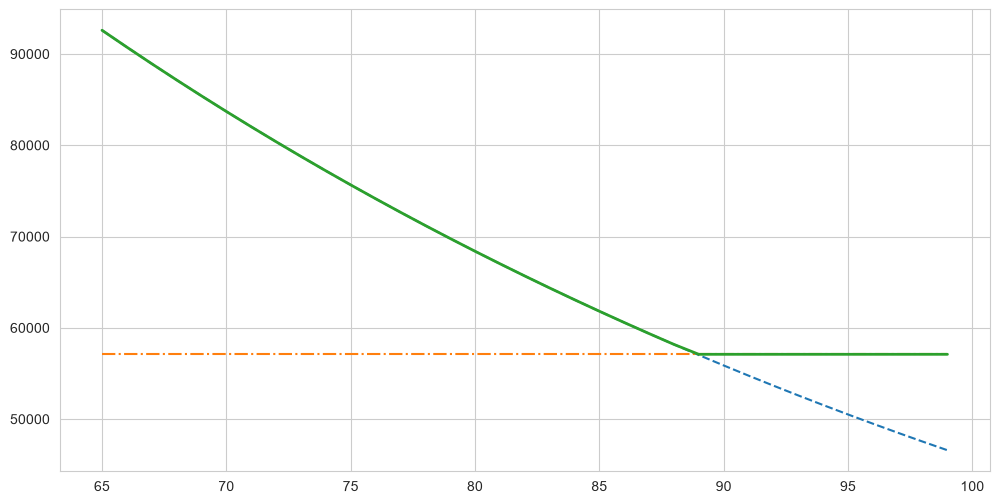

In [3]:
t = np.arange(0, SIMULATION_YEARS)
desired_spending_over_time = DESIRED_SPENDING * (1 - SPENDING_DECLINE_RATE) ** t
consumption_floor_over_time = CONSUMPTION_FLOOR * (1 - FLOOR_DECLINE_RATE) ** t
spending = np.maximum(desired_spending_over_time, consumption_floor_over_time)

plt.figure(figsize=(12, 6))
plt.plot(t+65, desired_spending_over_time, label='Desired Spending', linestyle='--')
plt.plot(t+65, consumption_floor_over_time, label='Consumption Floor', linestyle='-.')
plt.plot(t+65, spending, label='Effective Spending', linewidth=2)

In [ ]:
tax_rates = np.loadtxt("../Data/IID Data/Final/tax_rates.csv", delimiter=",", skiprows=1)

return_sampler_loaders = {}
for sampler_name in RETURN_SAMPLERS:
    if sampler_name == "cholesky":
        exp_returns = np.loadtxt("../Data/IID Data/Final/expected_returns.csv", delimiter=",", skiprows=1)
        cov_matrix = np.loadtxt(
            "../Data/IID Data/Final/covariance.csv", delimiter=",", skiprows=1, usecols=range(1, N_ASSETS + 2)
        )
        return_sampler_loaders[sampler_name] = CholeskyBootstrapReturns(exp_returns, cov_matrix)
    elif sampler_name in {"block_bootstrapped", "block_bootstrapped_1950"}:
        return_sampler_loaders[sampler_name] = BlockBootstrapReturnsLoader(
            f"../Data/Returns/Final/{sampler_name}.npy"
        )
    else:
        raise ValueError(f"Unknown RETURN_SAMPLER: {sampler_name}")

In [ ]:
from utils.experiment import (
    SimulationConfig,
    OptimizationResult,
    experiment_filename,
    save_experiment,
)

## Optimization

In [ ]:
# Setup optimizer and learning rate scheduler
from IPython.display import clear_output

wealth_penalty = SigmoidWealthPenalty(steepness=WEALTH_PENALTY_STEEPNESS)

for RETURN_SAMPLER in RETURN_SAMPLERS:
    return_sampler = return_sampler_loaders[RETURN_SAMPLER]
    returns_sample, cumulative_inflation_sample = return_sampler.generate(N_SIMULATIONS, SIMULATION_YEARS)
    returns = torch.tensor(returns_sample - tax_rates, device=DEVICE)
    cumulative_inflation = torch.tensor(cumulative_inflation_sample, device=DEVICE)

    print(f"\n{'='*70}")
    print(f"STARTING SAMPLER: {RETURN_SAMPLER}")
    print(f"{'='*70}")

    for INITIAL_WEALTH in INITIAL_WEALTH_RANGE:

        sim_config = SimulationConfig(
            N_ASSETS=N_ASSETS,
            N_SIMULATIONS=N_SIMULATIONS,
            SIMULATION_YEARS=SIMULATION_YEARS,
            RETURN_SAMPLER=RETURN_SAMPLER,
            INITIAL_WEALTH=INITIAL_WEALTH,
            DESIRED_SPENDING=DESIRED_SPENDING,
            SPENDING_DECLINE_RATE=SPENDING_DECLINE_RATE,
            CONSUMPTION_FLOOR=CONSUMPTION_FLOOR,
            FLOOR_DECLINE_RATE=FLOOR_DECLINE_RATE,
            INCOME_TYPE=INCOME_TYPE,
            INITIAL_POLICY=INITIAL_POLICY,
            OPTIMIZER_TYPE=OPTIMIZER_TYPE
        )

        # Configure spending and allocation policies
        desired_spending = DecliningRealSpending(DESIRED_SPENDING, decline_rate=SPENDING_DECLINE_RATE)
        consumption_floor = DecliningRealFloor(init_floor=CONSUMPTION_FLOOR, decline_rate=FLOOR_DECLINE_RATE)
        income = NZSuper(INCOME_TYPE)

        spending_policy = SpendingPolicy(
            spending=desired_spending,
            floor=consumption_floor,
            income=income
        )
        allocation_policy = ConstantAllocation(N_ASSETS, N_SIMULATIONS, DEVICE)

        # Initialize policy
        policy = torch.tensor(INITIAL_POLICY, device=DEVICE, dtype=torch.float32, requires_grad=True)

        # Choose optimizer based on configuration
        if OPTIMIZER_TYPE.upper() == "ADAM":
            optimizer = torch.optim.Adam([policy], lr=INITIAL_LR)
        else:
            optimizer = torch.optim.SGD([policy], lr=INITIAL_LR, momentum=MOMENTUM)

        cost_history = []
        policy_history = []

        # Tracking variables
        best_cost = float('inf')
        best_policy = policy.data.clone()
        iterations_without_improvement = 0
        iterations_without_lr_improvement = 0

        for i in range(MAX_ITERATIONS):
            optimizer.zero_grad()

            wealth, consumption = simulate_wealth_trajectory(
                returns=returns,
                cumulative_inflation=cumulative_inflation,
                allocation_policy=allocation_policy,
                spending_policy=spending_policy,
                initial_wealth=INITIAL_WEALTH,
                policy_settings=policy
            )
            cost = wealth_penalty.evaluate(wealth, consumption)

            cost.backward()
            optimizer.step()

            # Project onto feasible set (constraints: x >= 0, sum(x) <= 1)
            with torch.no_grad():
                policy.data = project_onto_simplex(policy.data)

            cost_item = cost.item()
            cost_history.append(cost_item)

            if (i + 1) % HISTORY_SAVE_FREQUENCY == 0:
                policy_history.append(policy.data.cpu().numpy().copy())

            if cost_item < best_cost:
                best_cost = cost_item
                best_policy = policy.data.clone()
                iterations_without_improvement = 0
                iterations_without_lr_improvement = 0
            else:
                iterations_without_improvement += 1
                iterations_without_lr_improvement += 1

            if iterations_without_improvement >= STOPPING_PATIENCE:
                print(f"\n{'='*70}")
                print(f"EARLY STOPPING at iteration {i + 1}")
                print(f"No improvement in {STOPPING_PATIENCE} iterations")
                print(f"{'='*70}")
                break

            if iterations_without_lr_improvement >= LR_PATIENCE:
                for param_group in optimizer.param_groups:
                    old_lr = param_group['lr']
                    new_lr = old_lr * LR_DECAY_FACTOR
                    param_group['lr'] = new_lr
                print(f"LR reduced at iteration {i+1}: {old_lr:.6f} -> {new_lr:.6f}")
                iterations_without_lr_improvement = 0

            # Progress reporting
            if (i + 1) % PRINT_EVERY == 0 or i == 0:
                clear_output(wait=True)

                current_lr = optimizer.param_groups[0]['lr']
                cost_change = cost_history[-1] - cost_history[-2] if len(cost_history) > 1 else 0
                print(f"{'='*70}")
                print(f"OPTIMISING: sampler={RETURN_SAMPLER} | wealth=${INITIAL_WEALTH:,.0f}")
                print(f"Iteration {i + 1:,}/{MAX_ITERATIONS:,} ({(i+1)/MAX_ITERATIONS*100:.1f}%) | LR: {current_lr:.6f}")
                print(f"{'='*70}")
                print(f"Cost:                      {cost_item:.6f}")
                print(f"Cost change:               {cost_change:.8f} (threshold: {LR_THRESHOLD})")
                print(f"Best Cost:                 {best_cost:.6f}")
                print(f"Iterations w/o improve:    {iterations_without_improvement}/{STOPPING_PATIENCE}")
                print(f"{'-'*70}")
                print(f"Current policy:            {policy.data.cpu().numpy()}")
                print(f"Best policy:               {best_policy.cpu().numpy()}")
                print(f"{'-'*70}")
                print(f"Mean consumption:          ${consumption.mean().item():,.0f}")
                print(f"Mean terminal wealth:      ${wealth[:, -1].mean().item():,.0f}")
                print(f"Bankruptcy rate:           {(wealth[:, -1] == 0).sum().item() / N_SIMULATIONS:.2%}")
                bankruptcy_density = (wealth == 0).sum().item() / (N_SIMULATIONS * SIMULATION_YEARS)

                floor = consumption_floor.calculate_tensor(wealth=wealth, cumulative_inflation=cumulative_inflation)
                impoverishment_density = (consumption < floor).sum().item() / (N_SIMULATIONS * SIMULATION_YEARS)

                print(f"Impoverishment density:    {impoverishment_density:.4%}")
                print(f"Bankruptcy density:        {bankruptcy_density:.4%}")
                print(f"{'='*70}")

        # Restore best policy found
        with torch.no_grad():
            policy.data = best_policy

        policy_history = np.array(policy_history)
        cost_history = np.array(cost_history)

        # Final summary
        print(f"\n{'='*70}")
        print(f"OPTIMIZATION COMPLETE - sampler={RETURN_SAMPLER} | wealth=${INITIAL_WEALTH:,.0f}")
        print(f"Best cost: {best_cost:.6f}  |  Iterations: {len(cost_history):,}")
        print(f"Best policy found:         {best_policy.cpu().numpy()}")
        print(f"{'='*70}")

        final_simulated_wealth, final_simulated_consumption = simulate_wealth_trajectory(
            returns=returns,
            cumulative_inflation=cumulative_inflation,
            allocation_policy=allocation_policy,
            spending_policy=spending_policy,
            initial_wealth=INITIAL_WEALTH,
            policy_settings=policy
        )

        result = OptimizationResult(
            best_policy=best_policy.detach().cpu().numpy(),
            best_utility=-best_cost,
            policy_history=policy_history,
            cost_history=cost_history,
            wealth_simulated=final_simulated_wealth.detach().cpu().numpy(),
            consumption_simulated=final_simulated_consumption.detach().cpu().numpy(),
            cumulative_inflation=cumulative_inflation.detach().cpu().numpy(),
        )
        print("Saving experiment results...")
        save_experiment(sim_config, result)

OPTIMIZING FOR INITIAL WEALTH: $1,225,000
Iteration 640/10,000 (6.4%) | LR: 0.025000
Cost:                      -0.998956
Cost change:               0.00000000 (threshold: 1e-05)
Best Cost:                 -0.998956
Iterations w/o improve:    387/400
----------------------------------------------------------------------
Current policy:            [0.        0.5259628]
Best policy:               [0.         0.52667284]
----------------------------------------------------------------------
Mean consumption:          $164,345
Mean terminal wealth:      $9,888,550
Bankruptcy rate:           0.49%
Impoverishment density:    0.1749%
Bankruptcy density:        0.1562%

EARLY STOPPING at iteration 653
No improvement in 400 iterations

OPTIMIZATION COMPLETE
Total iterations:          653
Final cost:                -0.998956
Best cost:                 -0.998956
Best policy found:         [0.         0.52667284]
Saving experiment results...
Experiment saved to Results/experiment_1225000_block_boo